In [3]:
import sounddevice as sd
from scipy.io.wavfile import write
from IPython.display import Audio, Image
import numpy as np
from audio_utils import plot_signal

# Configuration parameters
fs = 44100       # Sample rate (CD quality)
seconds = 5      # Duration of recording
filename = 'resources/output.wav'
filename2 = 'resources/output-playback.wav'
sd.default.samplerate = fs
sd.default.channels = 2

In [4]:
duration = 2.0      # seconds
freq = 440.0        # Hz (A4)

t = np.linspace(0, duration, int(fs * duration), endpoint=False)
sine = (0.5 * np.sin(2 * np.pi * freq * t)).astype(np.float32)   # 0.5 = headroom, avoids clipping

# pad with silence so the recording catches the tail after playback latency
sine = np.concatenate([sine, np.zeros(int(0.5 * fs), dtype=np.float32)])

# myrecording2 = sd.playrec(sine, fs, channels=1, dtype='float32')
# sd.wait()

# write(filename2, fs, myrecording2)
# or 16-bit PCM, which plays everywhere:
# write(filename2, fs, (np.clip(myrecording2, -1, 1) * 32767).astype(np.int16))

# Sampler

In [38]:
ceil = max(abs(sine))
samples=[ceil*i/5 for i in range(5,-6,-1)]

def leveler(l):
    for s in samples:
        if l > s:
            return s
    return 0

In [40]:
sampledSine = [leveler(s) for s in sine]

/Users/supun/Documents/Claude/Projects/phd/mir_project/.venv/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=200
  warnings.warn(


(<Figure size 1000x700 with 2 Axes>,
 (<Axes: title={'center': 'Waveform'}, xlabel='Time (s)', ylabel='Amplitude'>,
  <Axes: title={'center': 'Mean mel spectrum'}, xlabel='Frequency (Hz)', ylabel='Power (dB)'>))

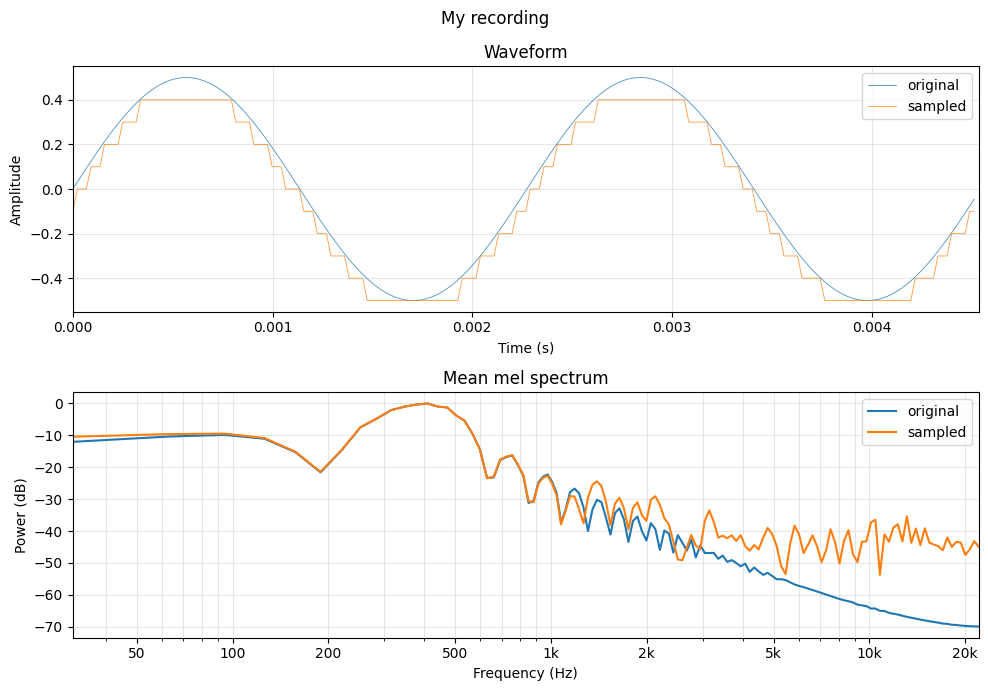

In [44]:
plot_signal({'original': sine[:200], 'sampled': sampledSine[:200]},fs, title='My recording')